<a href="https://colab.research.google.com/github/MaicolHernandez33/Actividad2Procesamiento/blob/main/analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Esta es la ruta directa a al archivo en GitHub
url = "https://raw.githubusercontent.com/MaicolHernandez33/Actividad2Procesamiento/main/players_20.csv"

df = pd.read_csv(url)

print(df.columns.tolist())
df.head()

['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas importantes para analizar
columnas_estudio = ['short_name', 'age', 'height_cm', 'weight_kg', 'overall', 'potential', 'value_eur', 'wage_eur']

# Creamos un nuevo DataFrame solo con las columnas
df_fifa = df[columnas_estudio].copy()

In [ ]:
df_fifa. describe()

,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000
mean,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773
std,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095
min,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000
25%,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000
50%,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000
75%,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000
max,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000


In [42]:
MediaEdad = df_fifa['age'].mean()
MedianaEdad = df_fifa['age'].median()
STDEdad = df_fifa['age'].std()
MinEdad = df_fifa['age'].min()
MaxEdad = df_fifa['age'].max()
ModaEdad = df_fifa['age'].mode()[0]



print('========= Análisis de las edades =========')
print("==========================================\n")
print(f" Edad Promedio:     {MediaEdad:.1f} años")
print(f" Mediana:           {MedianaEdad:.1f} años")
print(f" Jugador más Joven: {MinEdad:.0f} años")
print(f" Jugador Veterano:  {MaxEdad:.0f} años")
print(f" Edad más Común:    {ModaEdad} años")
print(f" Desviación (STD):  {STDEdad:.2f}\n\n")


# Cálculo de Cuartiles y Rango Intercuartílico (IQR)
Q1Edad = df_fifa['age'].quantile(0.25)
Q3Edad = df_fifa['age'].quantile(0.75)
IQREdad = Q3Edad - Q1Edad

# Límites (Regla de 1.5 veces el IQR)
limite_inferior = Q1Edad - 1.5 * IQREdad
limite_superior = Q3Edad + 1.5 * IQREdad

# Identificación de los Outliers
outliers_jovenes = df_fifa[df_fifa['age'] < limite_inferior]
outliers_veteranos = df_fifa[df_fifa['age'] > limite_superior]


print('========= DETECCIÓN DE OUTLIERS: EDAD =========')
print("===============================================\n")
print(f" Rango Intercuartílico (IQR): {IQREdad} años")
print(f" Límite para ser 'muy joven': {limite_inferior:.1f} años")
print(f" Límite para ser 'muy veterano': {limite_superior:.1f} años")
print(f" Cantidad de Outliers Jóvenes:   {len(outliers_jovenes)}")
print(f" Cantidad de Outliers Veteranos: {len(outliers_veteranos)}\n\n\n")


# outliers más veteranos
print("========== TOP 10: JUGADORES MÁS VETERANOS (OUTLIERS) ==========")
lista_ordenada = outliers_veteranos.sort_values('age', ascending=False)
lista_ordenada.head(10)

========= Análisis de las edades =========

 Edad Promedio:     25.3 años
 Mediana:           25.0 años
 Jugador más Joven: 16 años
 Jugador Veterano:  42 años
 Edad más Común:    22 años
 Desviación (STD):  4.66


========= DETECCIÓN DE OUTLIERS: EDAD =========

 Rango Intercuartílico (IQR): 7.0 años
 Límite para ser 'muy joven': 11.5 años
 Límite para ser 'muy veterano': 39.5 años
 Cantidad de Outliers Jóvenes:   0
 Cantidad de Outliers Veteranos: 19



========== TOP 10: JUGADORES MÁS VETERANOS (OUTLIERS) ==========


,short_name,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur
11832,C. Muñoz,42,177,73,64,64,50000,1000
13003,H. Sulaimani,42,173,70,63,63,0,5000
200,G. Buffon,41,192,92,83,83,2600000,58000
3706,C. Lucchetti,41,182,69,72,72,325000,5000
868,Hilton,41,180,78,78,78,0,21000
10665,F. Kippe,41,194,97,65,65,0,1000
1880,C. Pizarro,40,184,84,75,75,0,20000
4418,T. Howard,40,191,88,71,71,240000,3000
2963,D. Dainelli,40,191,78,73,73,0,2000
2965,Cifuentes,40,189,80,73,73,400000,4000


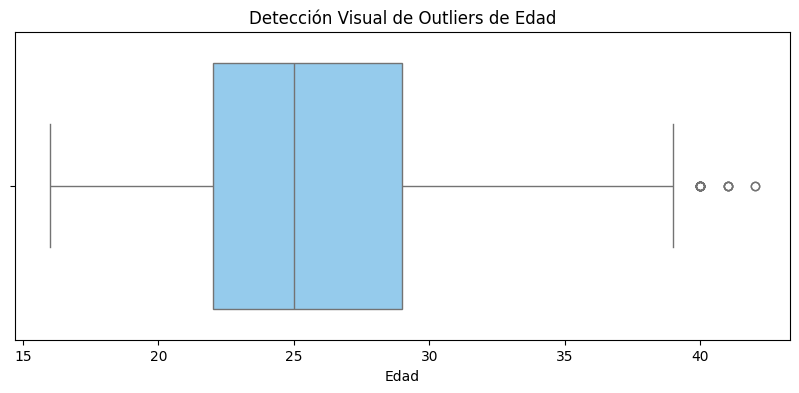

In [47]:
# --- Gráfico 1: El Boxplot (Outliers) ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_fifa['age'], color='lightskyblue')
plt.title('Detección Visual de Outliers de Edad')
plt.xlabel('Edad')
plt.show()